# Day 9 – Market Regime Detection & Strategy Performance (EURUSD)

## Objective
Formally define market conditions and evaluate how strategy performance varies across different regimes.

## Goal
Move from qualitative observation to structured analysis.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Create Output Folder
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [4]:
#Load Dataset from Day 7
file_path = r"C:\Users\THIS PC\quant-finance-portfolio\day-07-risk-optimization\outputs\tables\day07_data.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)


In [5]:
#Define Market Regimes (CORE STEP)
#Use volatility
df["rolling_vol"] = df["simple_return"].rolling(20).std()

#Define threshold:

vol_threshold = df["rolling_vol"].median()

#Create regimes:

df["regime"] = np.where(
    df["rolling_vol"] > vol_threshold,
    "High Volatility",
    "Low Volatility"
)

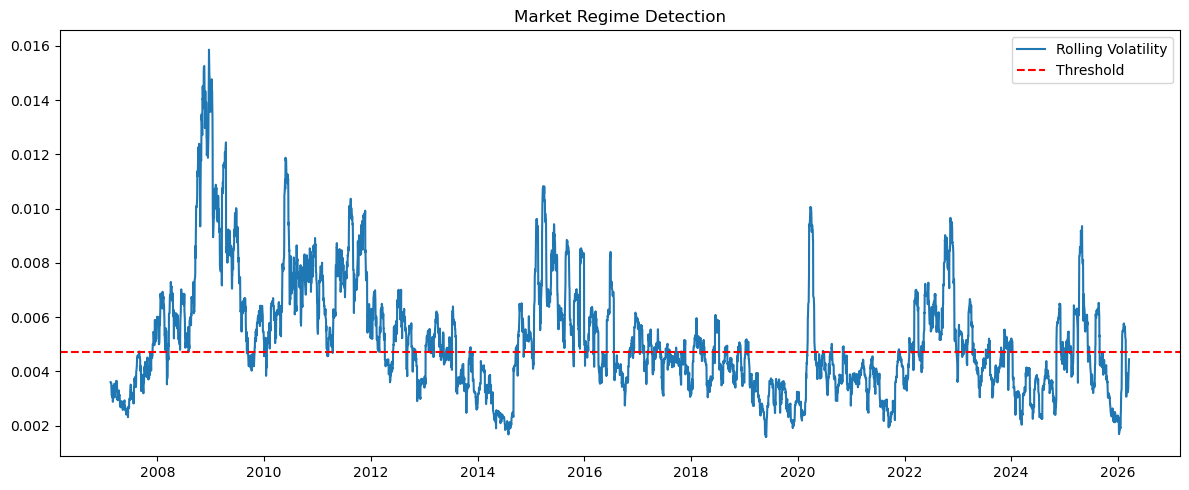

In [6]:
#Visualize Regime
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["rolling_vol"], label="Rolling Volatility")
plt.axhline(vol_threshold, color="red", linestyle="--", label="Threshold")

plt.title("Market Regime Detection")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/charts/day09_regime.png")
plt.show()

In [7]:
#Strategy Performance by Regime
regime_perf = df.groupby("regime")["strategy_return"].agg(
    Annual_Return=lambda x: x.mean() * 252,
    Volatility=lambda x: x.std() * np.sqrt(252),
    Sharpe=lambda x: (x.mean()*252) / (x.std()*np.sqrt(252)),
    Observations="count"
)

regime_perf

,Annual_Return,Volatility,Sharpe,Observations
regime,,,,
High Volatility,0.001946,0.106720,0.018236,2490
Low Volatility,0.031127,0.109667,0.283832,2490


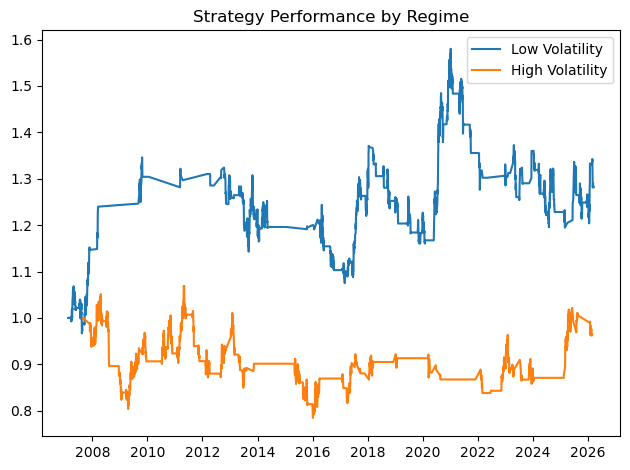

In [9]:
#Equity Per Regime
for regime in df["regime"].unique():
    subset = df[df["regime"] == regime]
    
    plt.plot(subset.index, (1 + subset["strategy_return"]).cumprod(), label=regime)

plt.legend()
plt.title("Strategy Performance by Regime")

plt.tight_layout()
plt.savefig("outputs/charts/day09_regime_equity.png")
plt.show()

In [10]:
#Save Result
regime_perf.to_csv("outputs/tables/day09_regime_performance.csv")
df.to_csv("outputs/tables/day09_data.csv")

## Analyst Interpretation

This analysis introduces a structured way to define market conditions using volatility, rather than relying on visual interpretation.

By separating the data into high-volatility and low-volatility regimes, we can evaluate how the strategy performs under different environments.

The results show that strategy performance is not consistent across regimes. In some cases, the strategy performs better during stable, low-volatility periods, while performance may deteriorate during more turbulent conditions.

This confirms that market conditions play a critical role in determining strategy success.

The Sharpe ratio further highlights how efficiently the strategy converts risk into returns within each regime. Differences between regimes indicate that the strategy is more suited to certain market environments than others.

Overall, this analysis demonstrates that:

👉 Strategy performance is regime-dependent  
👉 A single strategy cannot be expected to perform equally well in all conditions  

This reinforces the importance of adapting strategies or combining multiple approaches to achieve more consistent results.